In [ ]:
!pip install -q --upgrade pip
!pip install -q gensim
!pip install -q nltk wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.1 MB/s eta 0:00:00


In [ ]:
!pip install -q "gensim>=4.3.0" "numpy>=1.24"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Ai and ml/coursework/task 3/dataset/3. Financial Phrase Dataset/financial_phrase.csv', encoding='utf-8')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nLabel distribution:")
print(df['label'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (2264, 2)

First 5 rows:


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive



Label distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


EDA & Visualization

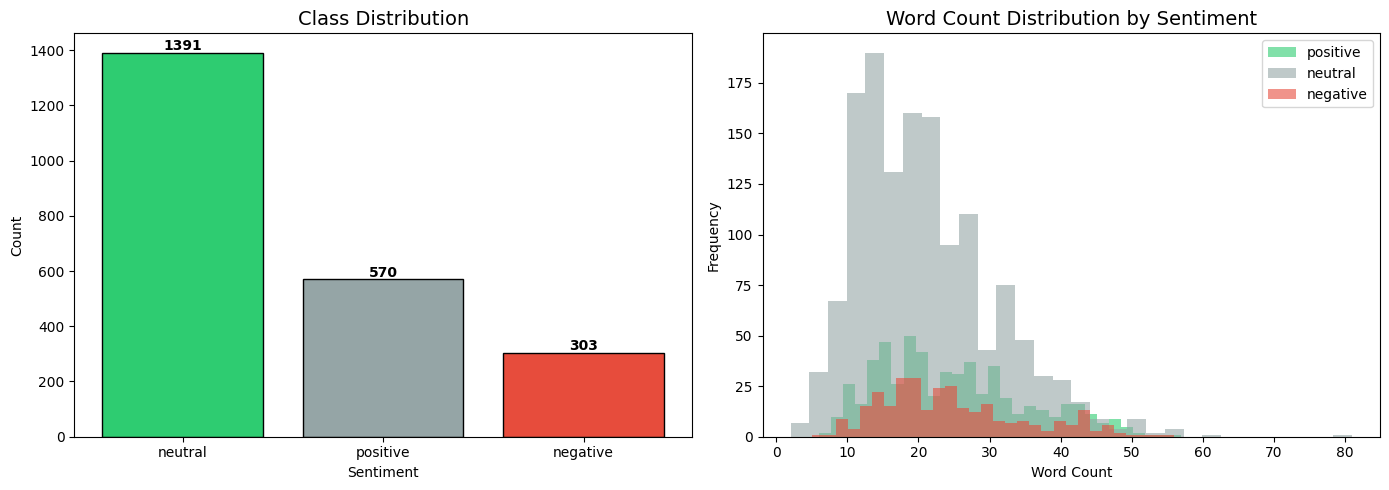


Average sentence length: 22.4 words
Max sentence length:     81 words
95th percentile length:  42 words


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['label'].value_counts()
colors = ['#2ecc71', '#95a5a6', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

df['text_length'] = df['text'].apply(lambda x: len(x.split()))
for label, color in zip(['positive', 'neutral', 'negative'], colors):
    subset = df[df['label'] == label]['text_length']
    axes[1].hist(subset, bins=30, alpha=0.6, label=label, color=color)
axes[1].set_title('Word Count Distribution by Sentiment', fontsize=14)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAverage sentence length: {df['text_length'].mean():.1f} words")
print(f"Max sentence length:     {df['text_length'].max()} words")
print(f"95th percentile length:  {int(np.percentile(df['text_length'], 95))} words")

Text Cleaning

In [ ]:
lemmatizer = WordNetLemmatizer()

# Keep negation words — critical for financial sentiment
STOP_WORDS = stopwords.words('english')
KEEP_WORDS = {'not', 'no', 'nor', 'never', 'neither', 'hardly', 'barely', 'scarcely'}
STOP_WORDS = [w for w in STOP_WORDS if w not in KEEP_WORDS]

CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "can't": "cannot", "couldn't": "could not",
    "wasn't": "was not", "weren't": "were not", "isn't": "is not",
    "aren't": "are not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not", "it's": "it is", "that's": "that is",
    "there's": "there is", "they're": "they are", "we're": "we are",
    "you're": "you are", "i'm": "i am", "i've": "i have",
    "i'll": "i will", "i'd": "i would", "they've": "they have",
    "we've": "we have", "we'll": "we will", "they'll": "they will"
}

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

def clean_text(text):
    text = text.lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove mentions
    text = re.sub(r'#\w+', '', text)                  # remove hashtags
    text = re.sub(r'\d+\.?\d*', 'NUM', text)          # replace numbers with token
    text = re.sub(r'[^\w\s]', '', text)               # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra spaces
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOP_WORDS]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

print("Original:")
print(df['text'].iloc[0])
print("\nCleaned:")
print(df['clean_text'].iloc[0])

Original:
According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .

Cleaned:
according gran company no plan move production russia although company growing


Word Cloud

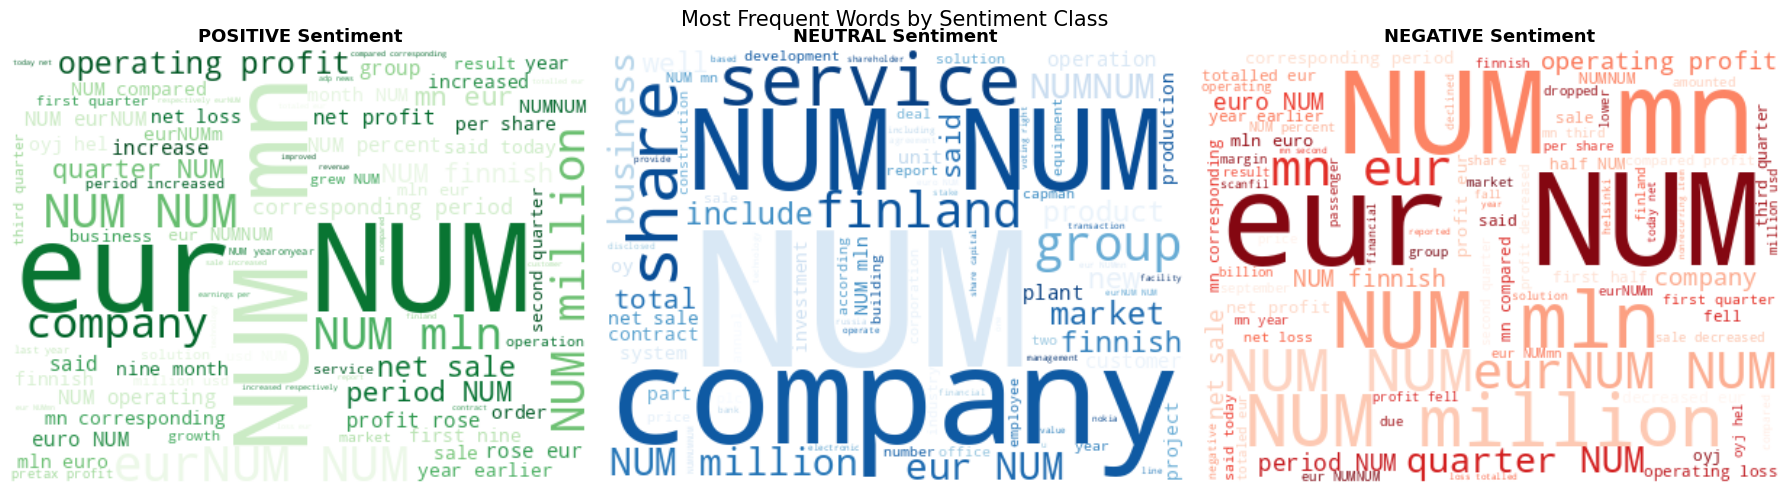

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
color_maps = ['Greens', 'Blues', 'Reds']
labels = ['positive', 'neutral', 'negative']

for ax, label, cmap in zip(axes, labels, color_maps):
    text_blob = ' '.join(df[df['label'] == label]['clean_text'])
    wc = WordCloud(width=400, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} Sentiment', fontsize=13, fontweight='bold')

plt.suptitle('Most Frequent Words by Sentiment Class', fontsize=15)
plt.tight_layout()
plt.show()

Label Encoding & Train/Val/Test Split


In [ ]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df['clean_text'].values
y = df['label_enc'].values

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Carve 15% of train out as validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Classes: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train: 1539 | Val: 272 | Test: 453


Tokenization & Padding

In [ ]:
VOCAB_SIZE = 8000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)  # fit only on train data

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding to avoid inflating from outliers
all_lens = [len(s) for s in X_train_seq]
MAX_LEN  = int(np.percentile(all_lens, 95))
print(f"Padding length (95th percentile): {MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"X_train_pad shape: {X_train_pad.shape}")

Padding length (95th percentile): 25
X_train_pad shape: (1539, 25)


Shared Settings & Callbacks

In [ ]:
EMBED_DIM = 64

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

Model 1: Simple RNN (Build)

In [ ]:
model1 = Sequential(name='SimpleRNN_Model')
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model1.add(SimpleRNN(64, return_sequences=False))
model1.add(Dropout(0.3))
model1.add(Dense(32, activation='relu'))
model1.add(Dense(NUM_CLASSES, activation='softmax'))

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model 1: Train

In [ ]:
history1 = model1.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=25,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6582 - loss: 0.8396 - val_accuracy: 0.7426 - val_loss: 0.6198 - learning_rate: 0.0010
Epoch 2/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7732 - loss: 0.5470 - val_accuracy: 0.7721 - val_loss: 0.5628 - learning_rate: 0.0010
Epoch 3/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8356 - loss: 0.3640 - val_accuracy: 0.7169 - val_loss: 0.6212 - learning_rate: 0.0010
Epoch 4/25
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8859 - loss: 0.2905
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8889 - loss: 0.2710 - val_accuracy: 0.8051 - val_loss: 0.5812 - learning_rate: 0.0010
Epoch 5/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9357 - loss: 0.1652 - val_accuracy: 0.7904 - val_loss: 0.5790 - learning_rate: 5.0000e-04
Epoch 6/25
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9593 - loss: 0.1258
Epoch 

Model 2: Bidirectional LSTM (Build)

In [ ]:
model2 = Sequential(name='BiLSTM_Model')
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model2.add(Bidirectional(LSTM(64, return_sequences=True)))
model2.add(Bidirectional(LSTM(32)))
model2.add(Dropout(0.4))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(NUM_CLASSES, activation='softmax'))

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model 2: Train

In [ ]:
history2 = model2.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=25,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - accuracy: 0.6140 - loss: 0.9279 - val_accuracy: 0.6507 - val_loss: 0.7948 - learning_rate: 0.0010
Epoch 2/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.7271 - loss: 0.6302 - val_accuracy: 0.7941 - val_loss: 0.4992 - learning_rate: 0.0010
Epoch 3/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8226 - loss: 0.3981 - val_accuracy: 0.7684 - val_loss: 0.5013 - learning_rate: 0.0010
Epoch 4/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8401 - loss: 0.3218
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.8447 - loss: 0.3265 - val_accuracy: 0.8015 - val_loss: 0.5176 - learning_rate: 0.0010
Epoch 5/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.8545 - loss: 0.2880 - val_accuracy: 0.7831 - val_loss: 0.5975 - learning_rate: 5.0000e-04
Epoch 6/25
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8551 - loss: 0.2540
Epoc

Download GloVe Embeddings

In [ ]:
import gensim.downloader as api

print("Downloading GloVe embeddings (this may take a few minutes)...")
embedding_model = api.load('glove-wiki-gigaword-50')
print("Download complete!")

[==================================================] 100.0% 66.0/66.0MB downloaded
Download complete!


Build Embedding Matrix

In [ ]:
GLOVE_DIM  = 50
word_index = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found = 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

coverage = 100 * found / min(len(word_index), VOCAB_SIZE)
print(f"Words covered by GloVe: {found} / {min(len(word_index), VOCAB_SIZE)} ({coverage:.1f}%)")

Words covered by GloVe: 3488 / 4090 (85.3%)


Model 3: LSTM + GloVe (Build)

In [ ]:
model3 = Sequential(name='LSTM_GloVe_Model')
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False          # frozen pre-trained weights
))
model3.add(LSTM(64, return_sequences=True))
model3.add(LSTM(32))
model3.add(Dropout(0.3))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(NUM_CLASSES, activation='softmax'))

model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 400,000 (1.53 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 400,000 (1.53 MB)

 Model 3: Train

In [ ]:
history3 = model3.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=25,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.6121 - loss: 0.8927 - val_accuracy: 0.7537 - val_loss: 0.6356 - learning_rate: 0.0010
Epoch 2/25
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7129 - loss: 0.6757
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7336 - loss: 0.6500 - val_accuracy: 0.7831 - val_loss: 0.5433 - learning_rate: 0.0010
Epoch 3/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7498 - loss: 0.5902 - val_accuracy: 0.7794 - val_loss: 0.5384 - learning_rate: 5.0000e-04
Epoch 4/25
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7768 - loss: 0.5251
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7602 - loss: 0.5537 - val_accuracy: 0.7904 - val_loss: 0.5330 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


Plot Training Curves (All 3 Models)

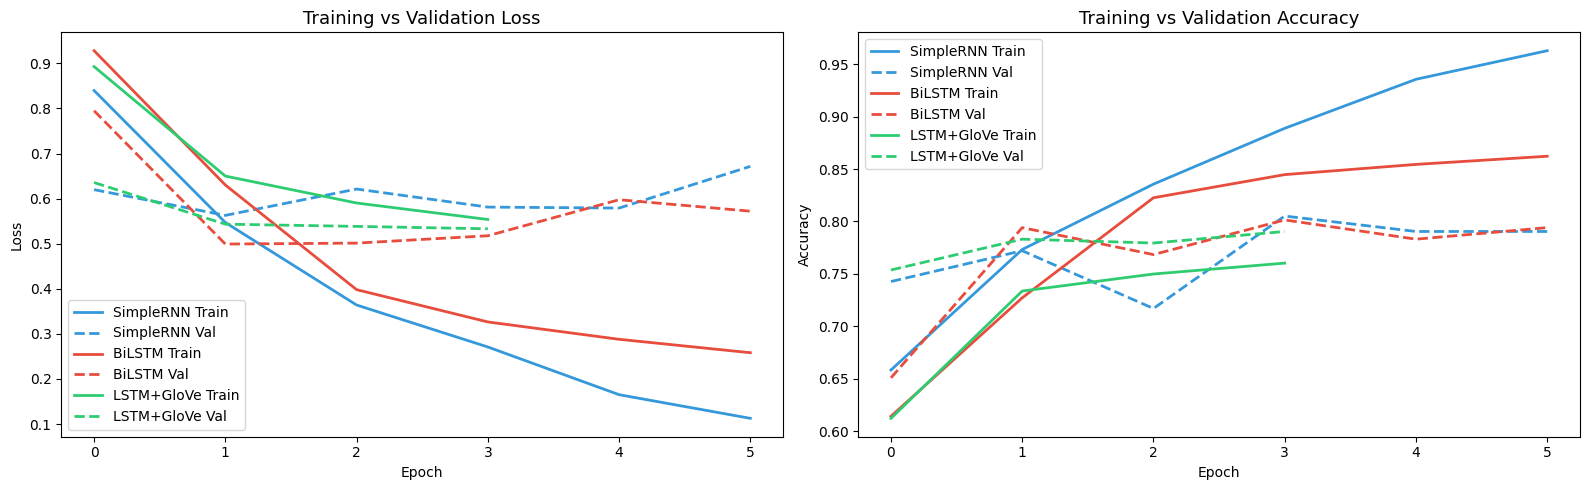

In [ ]:
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    for h, name, color in zip(histories, names, colors):
        axes[0].plot(h.history['loss'],         label=f'{name} Train', color=color, linewidth=2)
        axes[0].plot(h.history['val_loss'],     label=f'{name} Val',   color=color, linewidth=2, linestyle='--')
        axes[1].plot(h.history['accuracy'],     label=f'{name} Train', color=color, linewidth=2)
        axes[1].plot(h.history['val_accuracy'], label=f'{name} Val',   color=color, linewidth=2, linestyle='--')

    axes[0].set_title('Training vs Validation Loss', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].set_title('Training vs Validation Accuracy', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history([history1, history2, history3], ['SimpleRNN', 'BiLSTM', 'LSTM+GloVe'])

Evaluate All 3 Models


  Model: SimpleRNN
Test Accuracy : 0.7483
Test Loss     : 0.5878

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.92      0.87      0.90       278
    positive       0.51      0.84      0.64       114

    accuracy                           0.75       453
   macro avg       0.48      0.57      0.51       453
weighted avg       0.70      0.75      0.71       453



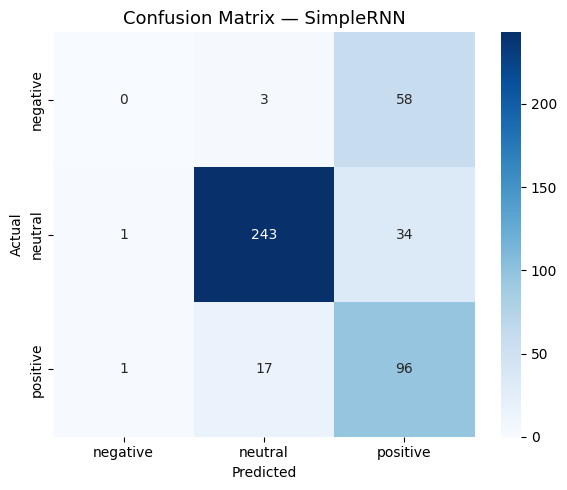


  Model: BiLSTM
Test Accuracy : 0.7528
Test Loss     : 0.5807

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.93      0.87      0.90       278
    positive       0.51      0.87      0.64       114

    accuracy                           0.75       453
   macro avg       0.48      0.58      0.51       453
weighted avg       0.70      0.75      0.71       453



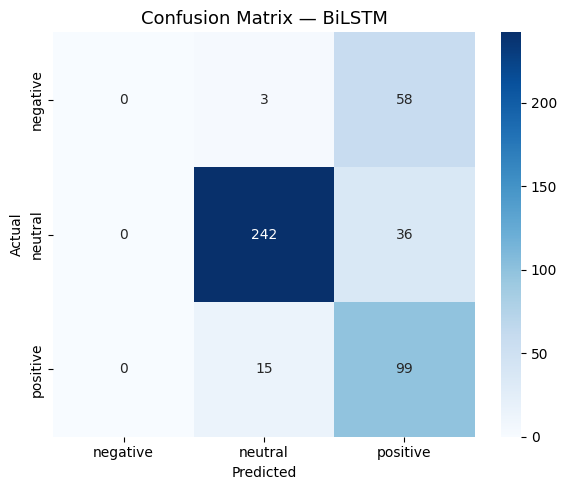


  Model: LSTM+GloVe
Test Accuracy : 0.6909
Test Loss     : 0.6816

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.82      0.87      0.84       278
    positive       0.45      0.63      0.53       114

    accuracy                           0.69       453
   macro avg       0.42      0.50      0.46       453
weighted avg       0.62      0.69      0.65       453



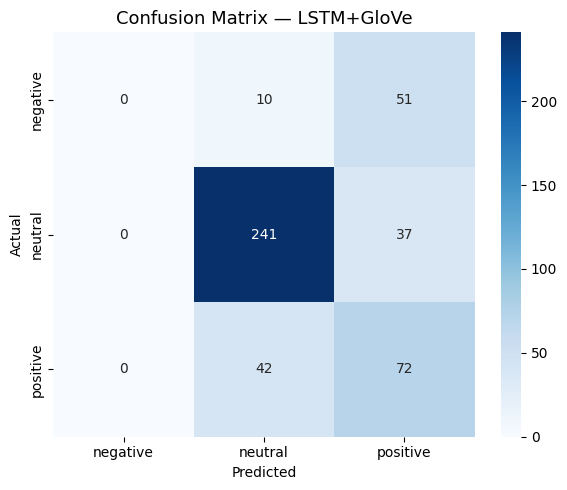

In [ ]:
def evaluate_model(model, X_test_pad, y_test, y_test_cat, name, classes):
    print(f"\n{'='*50}")
    print(f"  Model: {name}")
    print(f"{'='*50}")

    loss, acc = model.evaluate(X_test_pad, y_test_cat, verbose=0)
    print(f"Test Accuracy : {acc:.4f}")
    print(f"Test Loss     : {loss:.4f}")

    y_pred = np.argmax(model.predict(X_test_pad, verbose=0), axis=1)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=classes))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix — {name}', fontsize=13)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return acc, y_pred

classes = list(le.classes_)

acc1, pred1 = evaluate_model(model1, X_test_pad, y_test, y_test_cat, 'SimpleRNN',  classes)
acc2, pred2 = evaluate_model(model2, X_test_pad, y_test, y_test_cat, 'BiLSTM',     classes)
acc3, pred3 = evaluate_model(model3, X_test_pad, y_test, y_test_cat, 'LSTM+GloVe', classes)

Accuracy Bar Chart Comparison

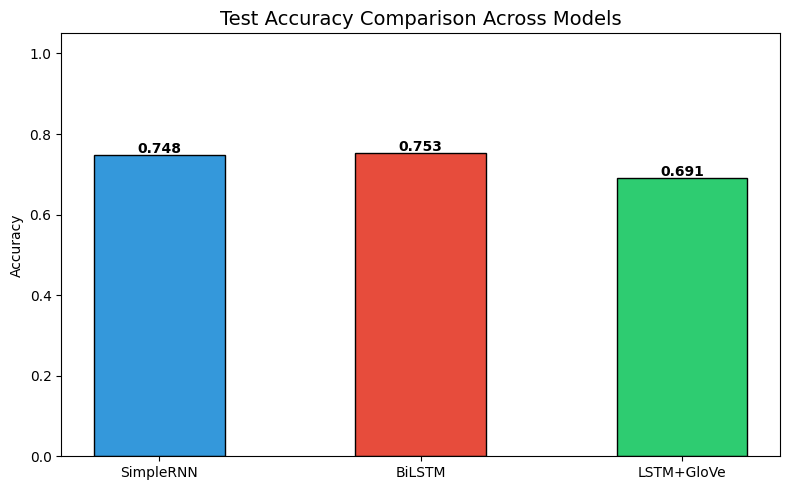

In [ ]:
model_names = ['SimpleRNN', 'BiLSTM', 'LSTM+GloVe']
accuracies  = [acc1, acc2, acc3]
colors      = ['#3498db', '#e74c3c', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontweight='bold')
plt.ylim(0, 1.05)
plt.title('Test Accuracy Comparison Across Models', fontsize=14)
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

 Error Analysis

Total misclassified (LSTM+GloVe): 140 / 453

--- 3 Example Misclassifications ---

Example 1:
  Text:      september alone market declined NUM percent yearonyear NUM million liter
  Actual:    negative
  Predicted: positive

Example 2:
  Text:      goodwill intangible asset account NUM mln euro NUM mln purchase price NUM pct payable aspo share
  Actual:    neutral
  Predicted: positive

Example 3:
  Text:      major order india comptel corporation received significant longterm order mediation provisioning solution used leading o
  Actual:    positive
  Predicted: neutral



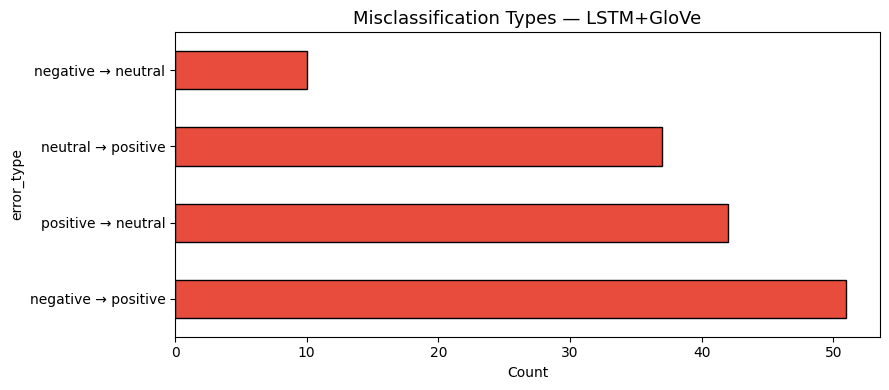

In [ ]:
test_df = pd.DataFrame({
    'original_text': X_test,
    'actual':        le.inverse_transform(y_test),
    'predicted_m3':  le.inverse_transform(pred3)
})

misclassified = test_df[test_df['actual'] != test_df['predicted_m3']]
print(f"Total misclassified (LSTM+GloVe): {len(misclassified)} / {len(test_df)}\n")
print("--- 3 Example Misclassifications ---\n")

for i, (_, row) in enumerate(misclassified.head(3).iterrows()):
    print(f"Example {i+1}:")
    print(f"  Text:      {row['original_text'][:120]}")
    print(f"  Actual:    {row['actual']}")
    print(f"  Predicted: {row['predicted_m3']}")
    print()

# Error type breakdown chart
misclassified = misclassified.copy()
misclassified['error_type'] = misclassified['actual'] + ' → ' + misclassified['predicted_m3']
error_counts = misclassified['error_type'].value_counts()

plt.figure(figsize=(9, 4))
error_counts.plot(kind='barh', color='#e74c3c', edgecolor='black')
plt.title('Misclassification Types — LSTM+GloVe', fontsize=13)
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
!pip install gradio -q

Gradio GUI

In [ ]:
import gradio as gr

def predict_sentiment(input_text, model_choice):
    if not input_text.strip():
        return "Please enter some text."

    cleaned = clean_text(input_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    model_map = {
        'SimpleRNN':  model1,
        'BiLSTM':     model2,
        'LSTM+GloVe': model3
    }

    probs      = model_map[model_choice].predict(padded, verbose=0)[0]
    pred_label = le.inverse_transform([np.argmax(probs)])[0]

    result = f"Sentiment: {pred_label.upper()}\n\n"
    for cls, p in zip(le.classes_, probs):
        bar = '█' * int(p * 20)
        result += f"{cls:8s}: {bar} {p:.2%}\n"
    return result

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=[
        gr.Textbox(lines=3, placeholder="Enter a financial news sentence...", label="Input Text"),
        gr.Dropdown(['SimpleRNN', 'BiLSTM', 'LSTM+GloVe'], value='LSTM+GloVe', label="Select Model")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Financial News Sentiment Analyzer",
    description="Classify financial sentences as Positive, Neutral, or Negative.",
    examples=[
        ["The company reported a significant increase in quarterly profits.", "LSTM+GloVe"],
        ["Operating profit fell by 15% compared to last year.", "BiLSTM"],
        ["The board announced no changes to the dividend policy.", "SimpleRNN"]
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b4832036b3e433b0ba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
